In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from preprocessing_module import Preprocess
from data_visualiser_module import DataVisualiser

# Load Datasets

 Load the datasets for the years 2021-2024 for energy consumption and production of Switzerland

In [3]:
# path 
path="../data/raw/"
years=[2021,2022,2023]

In [4]:
data = pd.concat([pd.read_excel(f"{path}EnergieUebersichtCH-{year}.xlsx",sheet_name='Zeitreihen0h15') for year in years], ignore_index=True)

# Dataset Info

In [5]:
data.head()

,Unnamed: 0,Summe endverbrauchte Energie Regelblock Schweiz\nTotal energy consumed by end users in the Swiss controlblock,Summe produzierte Energie Regelblock Schweiz\nTotal energy production Swiss controlblock,Summe verbrauchte Energie Regelblock Schweiz\nTotal energy consumption Swiss controlblock,Netto Ausspeisung aus dem Übertragungsnetz Schweiz\nNet outflow of the Swiss transmission grid,Vertikale Einspeisung ins Übertragungsnetz Schweiz\nGrid feed-in Swiss transmission grid,Positive Sekundär-Regelenergie\nPositive secundary control energy,Negative Sekundär-Regelenergie\nNegative secundary control energy,Positive Tertiär-Regelenergie\nPositive tertiary control energy,Negative Tertiär-Regelenergie\nNegative tertiary control energy,...,"Produktion Kantone OW, NW, UR\nProduction Cantons OW, NW, UR","Verbrauch Kantone OW, NW, UR\nConsumption Cantons OW, NW, UR","Produktion Kantone GE, VD\nProduction Cantons GE, VD","Verbrauch Kantone GE, VD\nConsumption Cantons GE, VD","Produktion Kantone SH, ZH\nProduction Cantons SH, ZH","Verbrauch Kantone SH, ZH\nConsumption Cantons SH, ZH",Produktion Kantonsübergreifend\nProduction across Cantons,Verbrauch Kantonsübergreifend\nConsumption across Cantons,Produktion Regelzone CH - Ausländische Gebiete\nProduction control area CH - foreign territories,Verbrauch Regelzone CH - Ausländische Gebiete\nConsumption control area CH - foreign territories
0,Zeitstempel,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,...,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh
1,01.01.2021 00:15,1671630.088625,1210856.088,1880710.202024,635189.489912,869233.8751,17242,-2392,0,0,...,9768.566,32685.315,27109.446,260040.413,20405.967,278109.595,97665.574,39143.313088,866.686,13374.112
2,01.01.2021 00:30,1661251.405625,1192987.411,1877758.191115,647088.60469,863927.1974,2639,-431,0,0,...,9764.704,32658.413,24469.448,260521.051,20517.589,277796.491,97445.697,42522.34031,822.455,13178.706
3,01.01.2021 00:45,1641591.90225,1194179.748,1854953.225189,625842.285412,864593.4948,230,-574,0,0,...,9181.536,32633.269,23613.422,257754.89,20614.251,273597.39,97301.079,39361.129588,615.664,12764.405
4,01.01.2021 01:00,1627956.774625,1188029.012,1847096.580761,621354.563153,857114.1599,126,-2521,0,0,...,6632.47,31527.531,23336.463,255148.58,20454.126,269694.877,97292.006,41680.276847,618.147,12354.812


drop empty unnecessary row,and rename unnamed column

In [6]:
#rename 
df=Preprocess(data)
df.rename_column('Unnamed: 0', 'Date')

Unnamed: 0 renamed to Date


drop

In [7]:
df.drop(rows=0)

[0] have been dropped


# Data overview

- df.describe(), df.info() and count missing values

In [8]:
df.data_overview()

Basic data overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105122 entries, 1 to 105122
Data columns (total 65 columns):
 #   Column                                                                                                        Non-Null Count   Dtype 
---  ------                                                                                                        --------------   ----- 
 0   Date                                                                                                          105122 non-null  object
 1   Summe endverbrauchte Energie Regelblock Schweiz
Total energy consumed by end users in the Swiss controlblock  105122 non-null  object
 2   Summe produzierte Energie Regelblock Schweiz
Total energy production Swiss controlblock                       105122 non-null  object
 3   Summe verbrauchte Energie Regelblock Schweiz
Total energy consumption Swiss controlblock                      105122 non-null  object
 4   Netto Ausspeisung aus dem Über

In [9]:
df.data.dtypes

Date                                                                                                             object
Summe endverbrauchte Energie Regelblock Schweiz\nTotal energy consumed by end users in the Swiss controlblock    object
Summe produzierte Energie Regelblock Schweiz\nTotal energy production Swiss controlblock                         object
Summe verbrauchte Energie Regelblock Schweiz\nTotal energy consumption Swiss controlblock                        object
Netto Ausspeisung aus dem Übertragungsnetz Schweiz\nNet outflow of the Swiss transmission grid                   object
                                                                                                                  ...  
Verbrauch Kantone SH, ZH\nConsumption Cantons SH, ZH                                                             object
Produktion Kantonsübergreifend\nProduction across Cantons                                                        object
Verbrauch Kantonsübergreifend\nConsumpti

convert to datae time

In [10]:
# date time 
df.convert_to_datetime('Date')

Rename the columns

In [11]:
# Rename column
df.rename_column('Summe endverbrauchte Energie Regelblock Schweiz\nTotal energy consumed by end users in the Swiss controlblock', 'End user energy consumtion(KWH)')
df.rename_column('Summe produzierte Energie Regelblock Schweiz\nTotal energy production Swiss controlblock', 'Total energy production(KWH)',)
df.rename_column('Summe verbrauchte Energie Regelblock Schweiz\nTotal energy consumption Swiss controlblock','Total energy consumption Swiss controlblock(KWH)')
df.rename_column('Vertikale Einspeisung ins Übertragungsnetz Schweiz\nGrid feed-in Swiss transmission grid','Grid feed-in Swiss transmission grid')
df.rename_column('Netto Ausspeisung aus dem Übertragungsnetz Schweiz\nNet outflow of the Swiss transmission grid','Net outflow of the Swiss transmission grid')

Summe endverbrauchte Energie Regelblock Schweiz
Total energy consumed by end users in the Swiss controlblock renamed to End user energy consumtion(KWH)
Summe produzierte Energie Regelblock Schweiz
Total energy production Swiss controlblock renamed to Total energy production(KWH)
Summe verbrauchte Energie Regelblock Schweiz
Total energy consumption Swiss controlblock renamed to Total energy consumption Swiss controlblock(KWH)
Vertikale Einspeisung ins Übertragungsnetz Schweiz
Grid feed-in Swiss transmission grid renamed to Grid feed-in Swiss transmission grid
Netto Ausspeisung aus dem Übertragungsnetz Schweiz
Net outflow of the Swiss transmission grid renamed to Net outflow of the Swiss transmission grid


Extract the columns needed

In [12]:
df_energy=df.data.copy()
columns_to_extract=['End user energy consumtion(KWH)',
                    'Total energy production(KWH)',
                    'Total energy consumption Swiss controlblock(KWH)',
                    'Net outflow of the Swiss transmission grid',
                    'Grid feed-in Swiss transmission grid']
df_energy=df_energy[columns_to_extract]


In [13]:
df_energy.head()

,End user energy consumtion(KWH),Total energy production(KWH),Total energy consumption Swiss controlblock(KWH),Net outflow of the Swiss transmission grid,Grid feed-in Swiss transmission grid
Date,,,,,
2021-01-01 00:15:00,1671630.088625,1210856.088,1880710.202024,635189.489912,869233.8751
2021-01-01 00:30:00,1661251.405625,1192987.411,1877758.191115,647088.60469,863927.1974
2021-01-01 00:45:00,1641591.90225,1194179.748,1854953.225189,625842.285412,864593.4948
2021-01-01 01:00:00,1627956.774625,1188029.012,1847096.580761,621354.563153,857114.1599
2021-01-01 01:15:00,1654789.95175,1233025.852,1901830.189312,631406.874869,888966.8143


In [14]:
# resample the columns needed and aggregate them
df_energy = df_energy.resample('h').agg({
    'End user energy consumtion(KWH)': 'sum',  
    'Total energy production(KWH)': 'sum',  
    'Total energy consumption Swiss controlblock(KWH)': 'sum',
    'Net outflow of the Swiss transmission grid':'sum',
    'Grid feed-in Swiss transmission grid':'sum'
})

# Plots

Instanciate the DataVisualiser class

In [15]:
df_energy_plots=DataVisualiser(df_energy)

## Outliers

### monthly

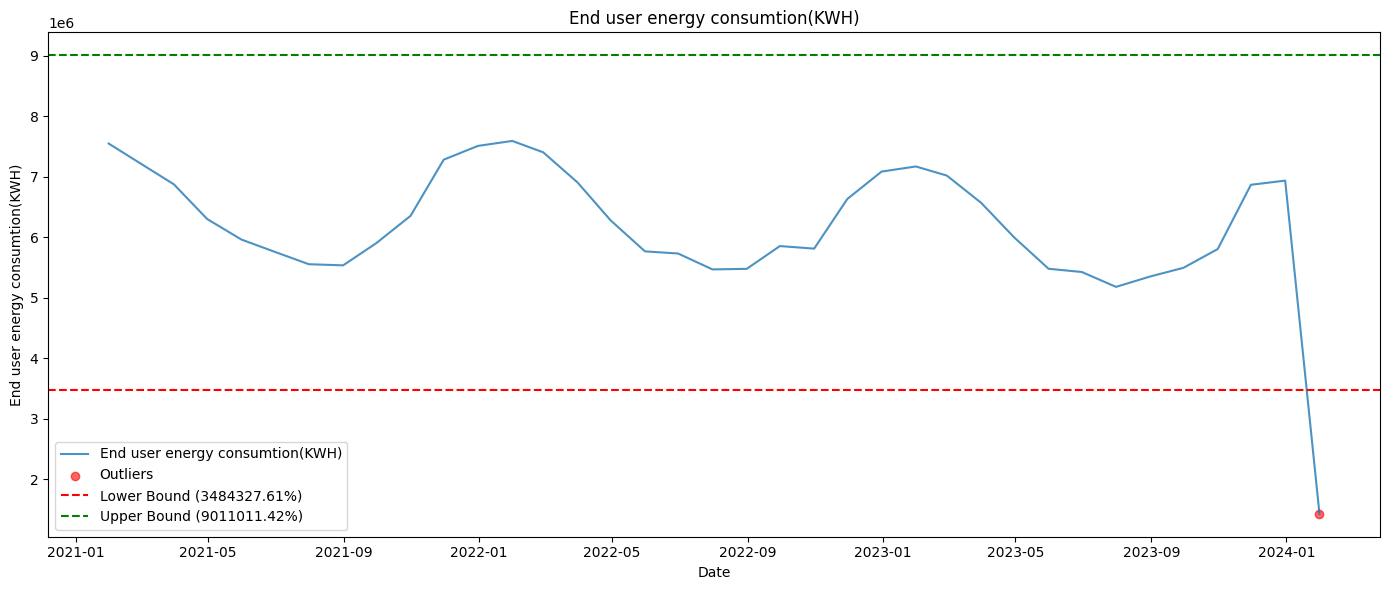

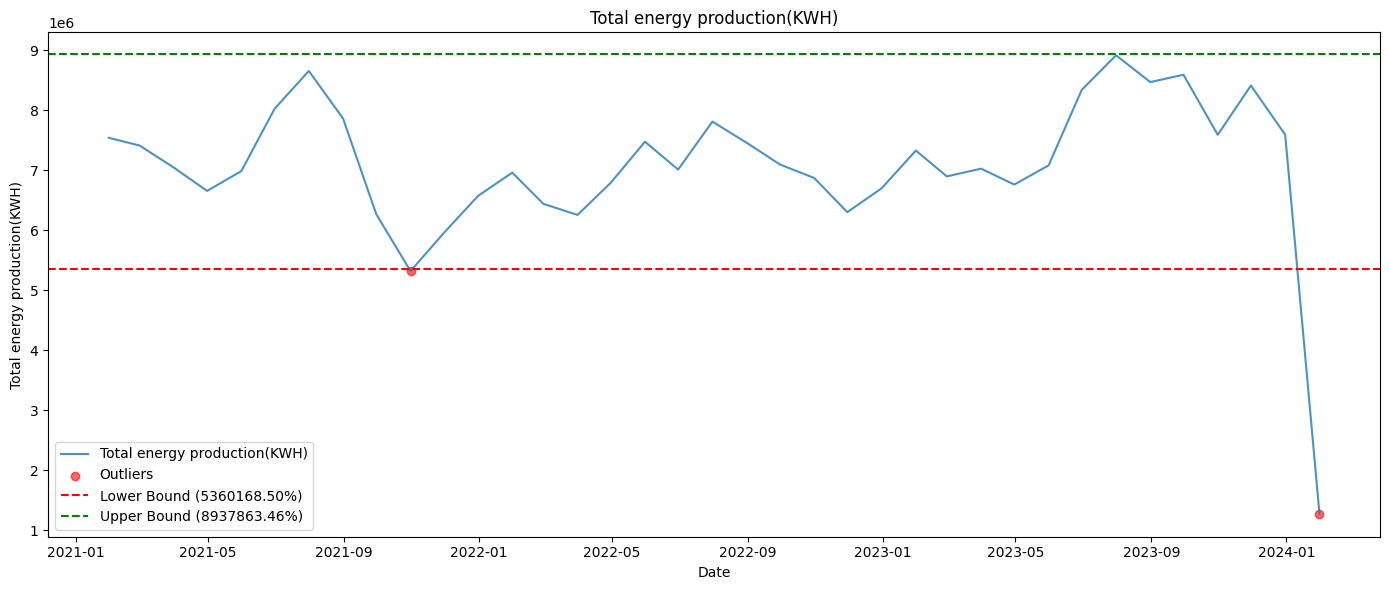

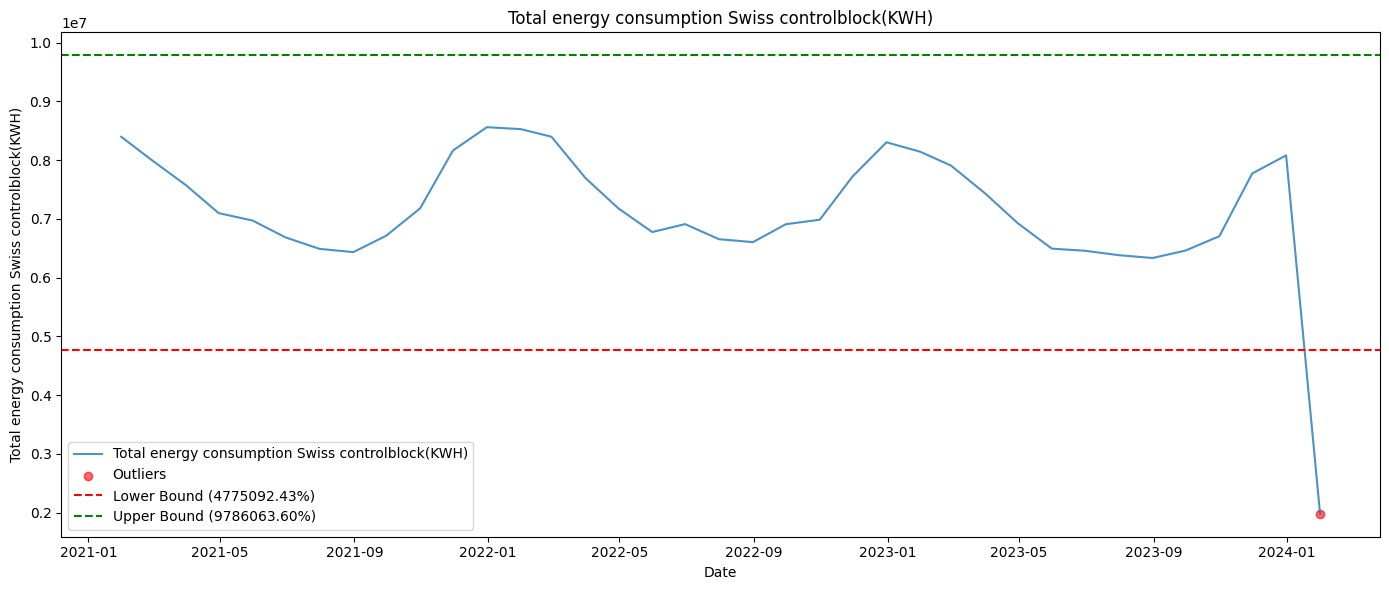

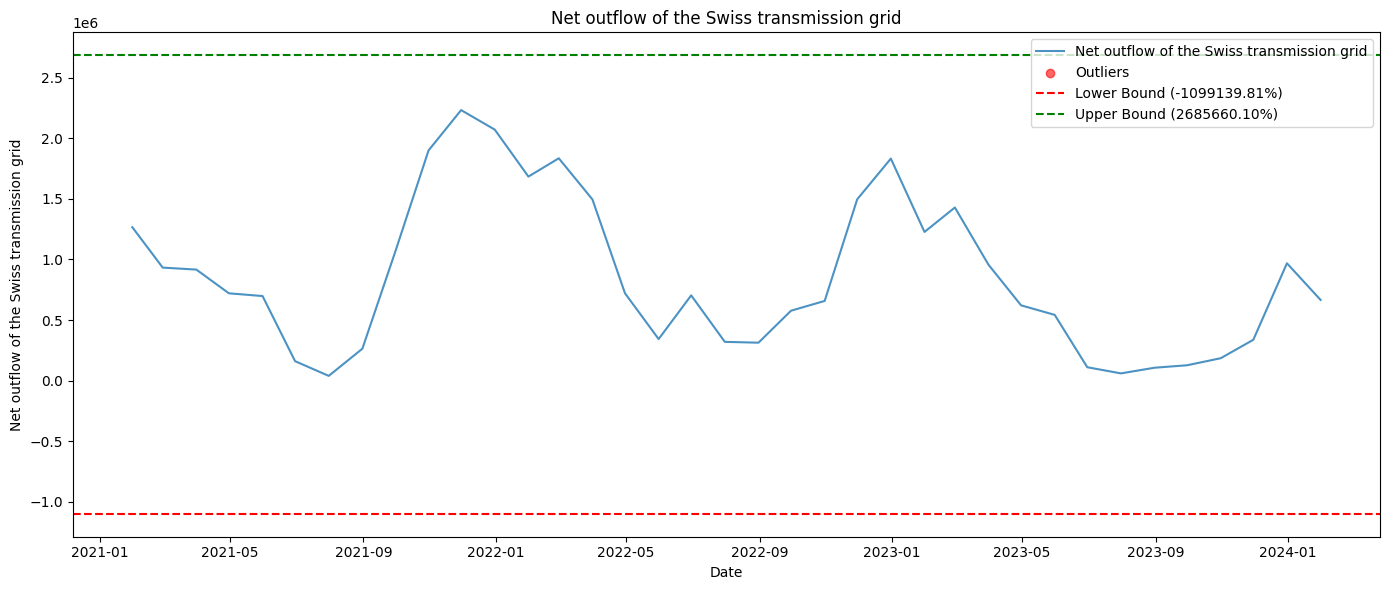

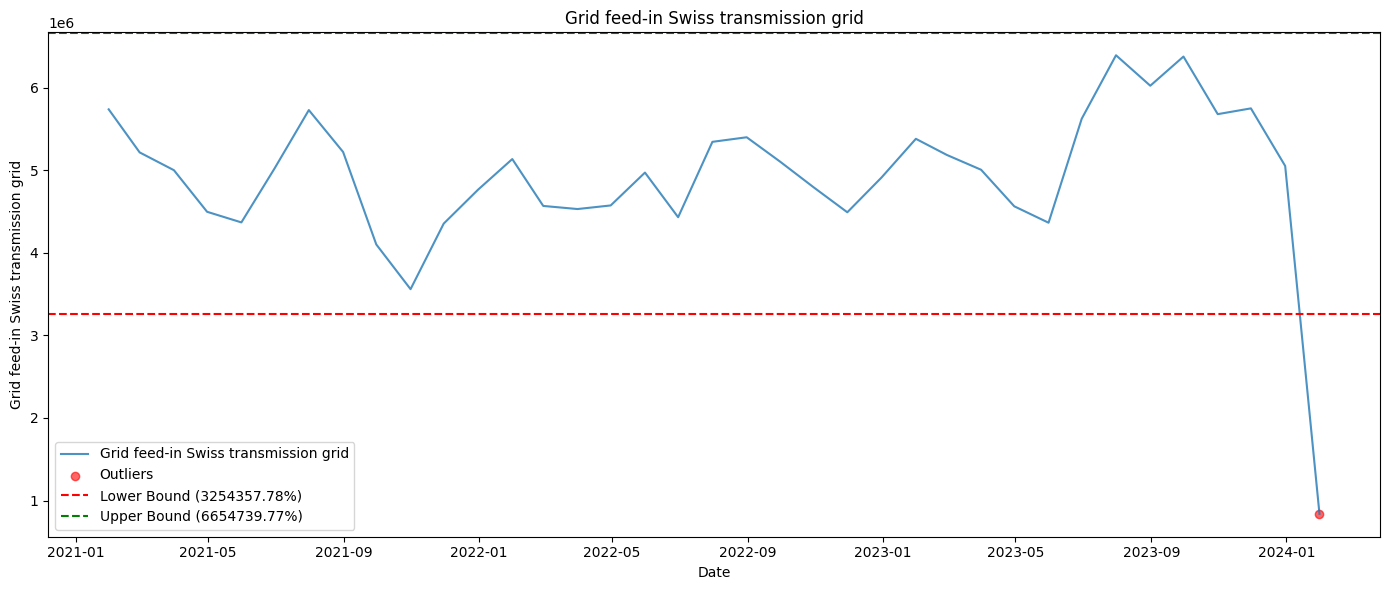

In [16]:
# plot monthly outlier
for column in df_energy_plots.data.columns:
    df_energy_plots.outlier_plot(column_name=column,title=f'{column}',group_by='month')

### weekly

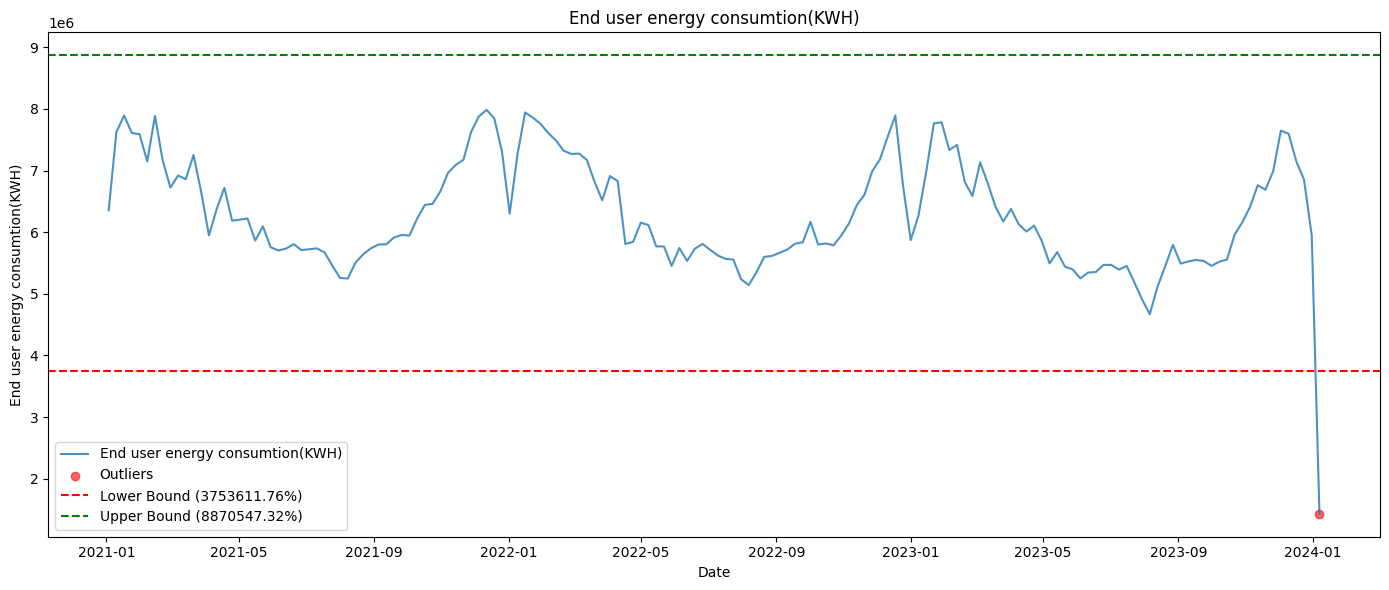

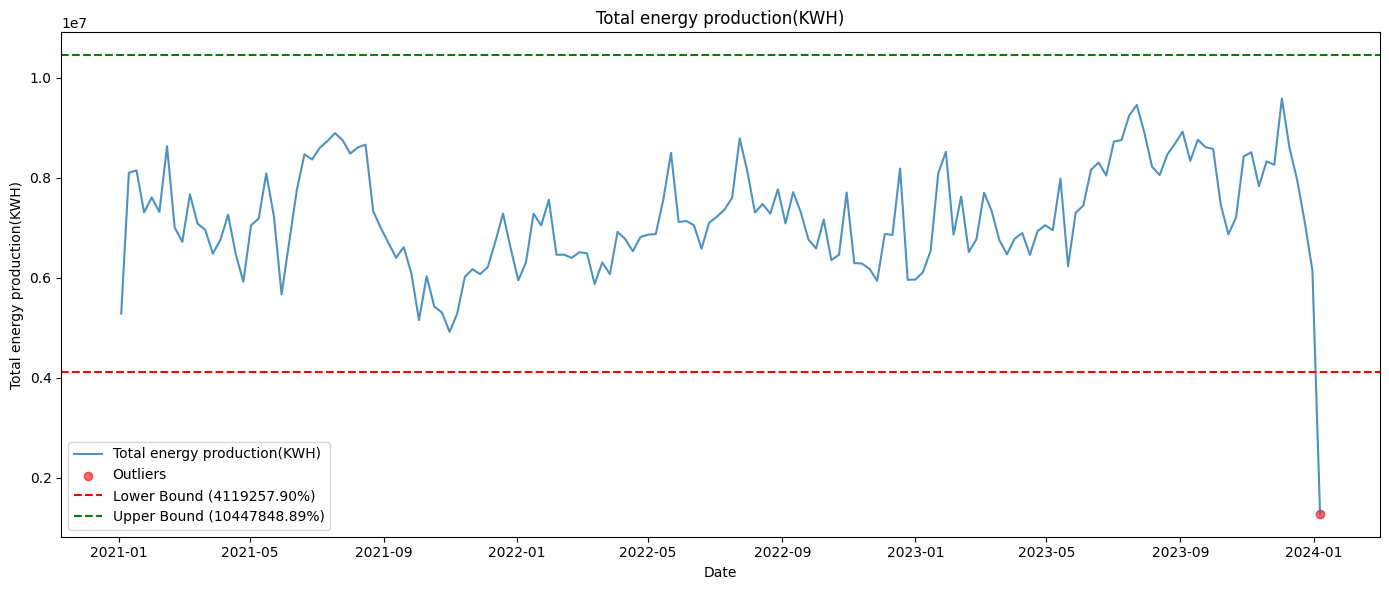

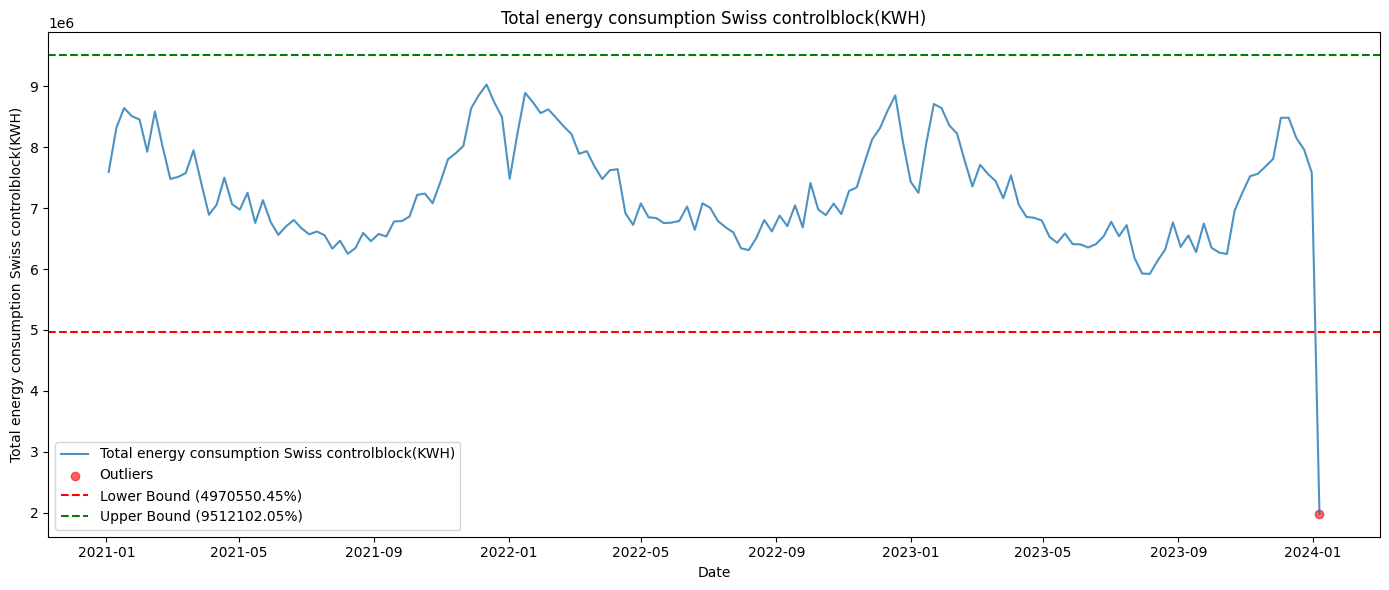

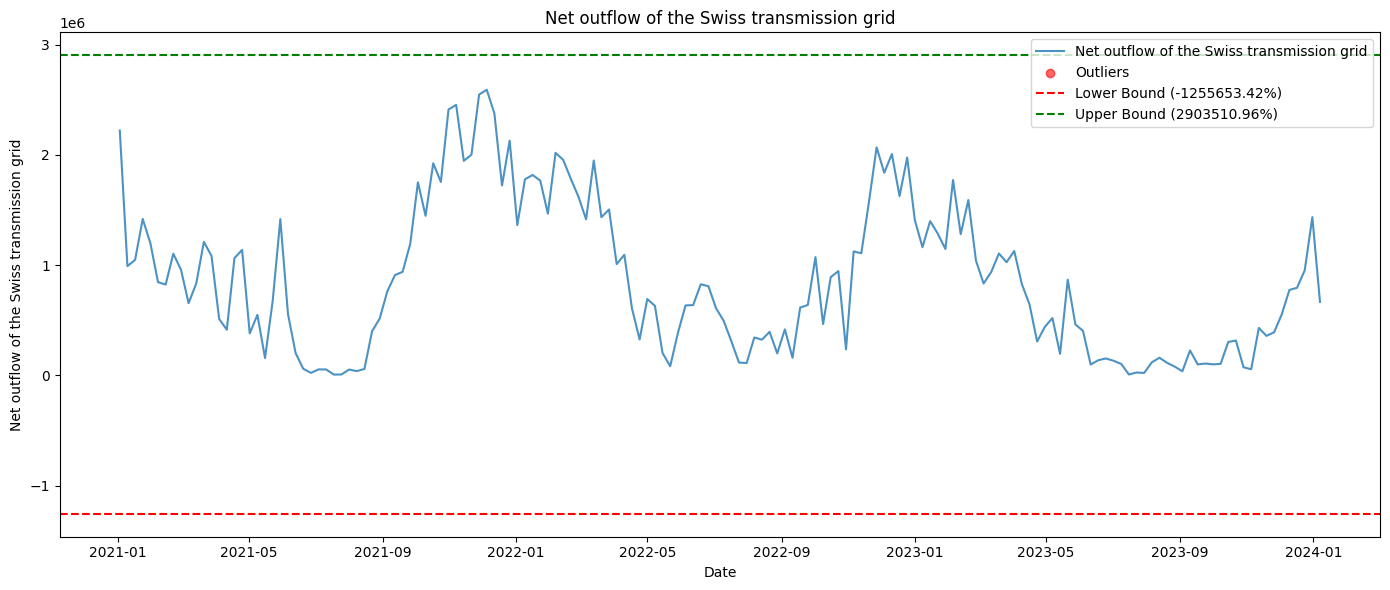

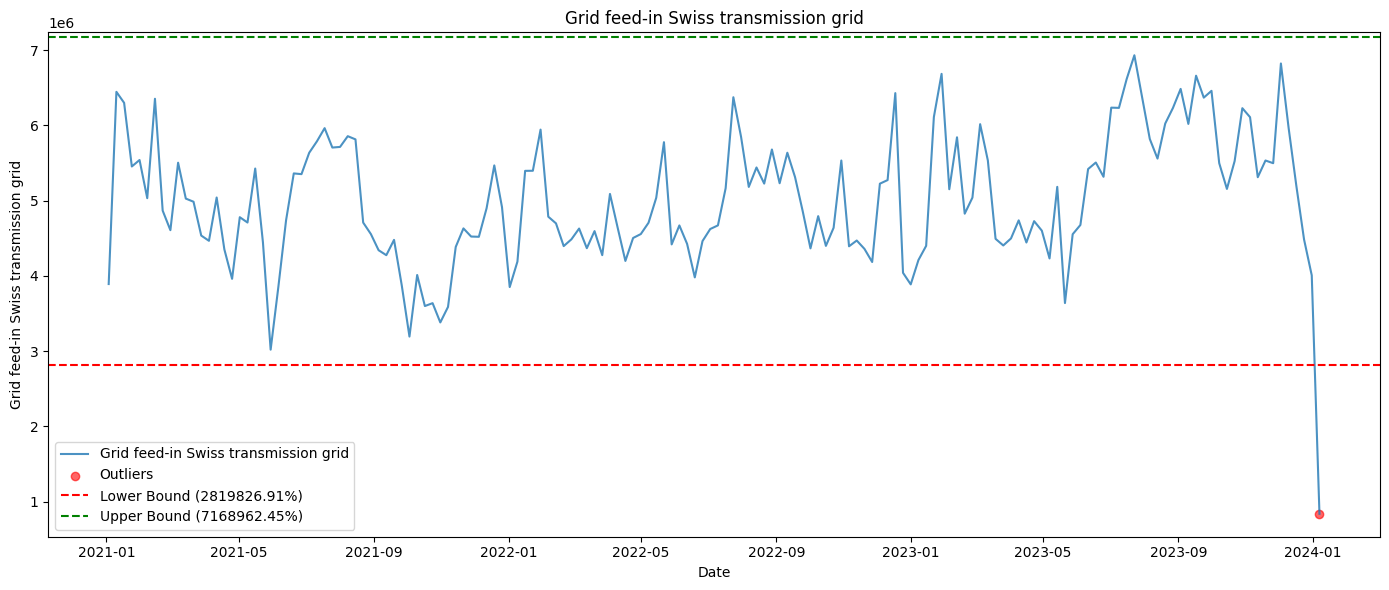

In [17]:
# plot weekly outlier
for column in df_energy_plots.data.columns:
    df_energy_plots.outlier_plot(column_name=column,title=f'{column}',group_by='week')

### Daily

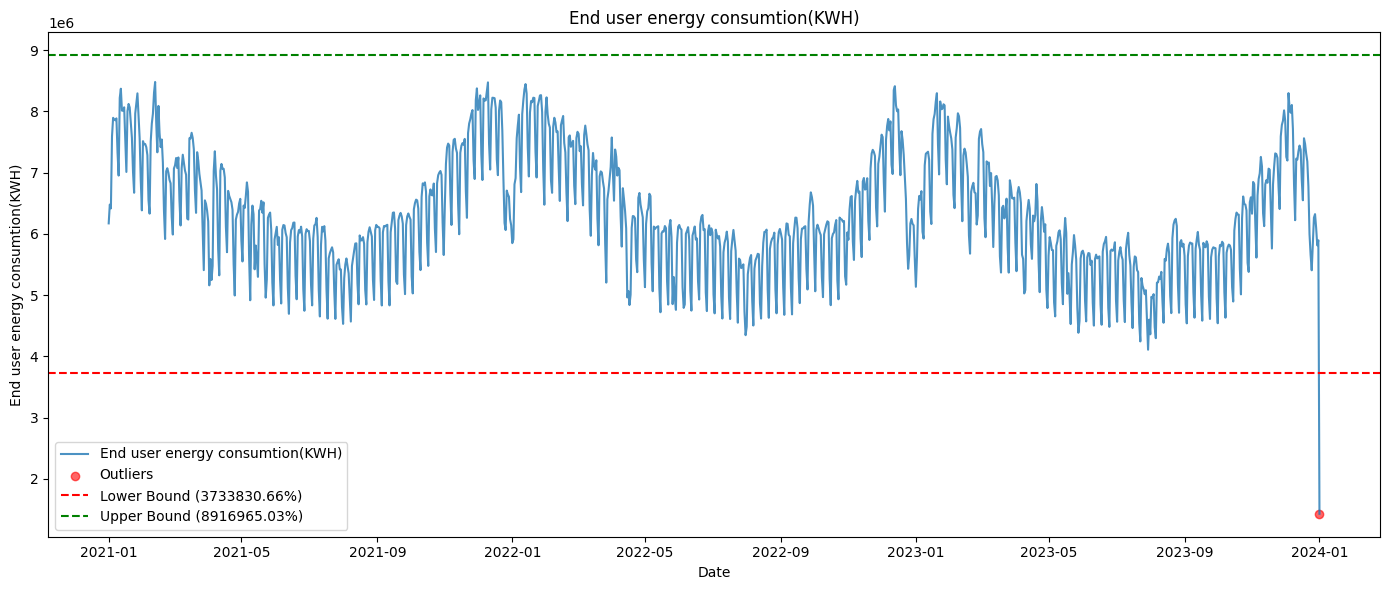

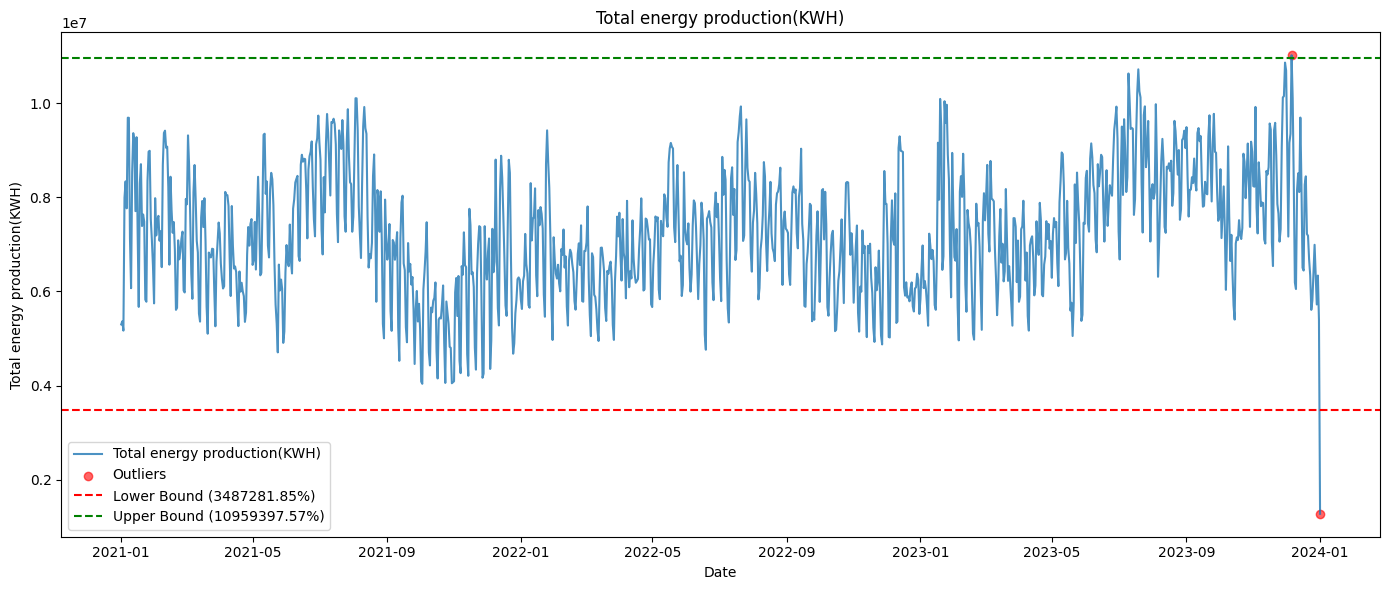

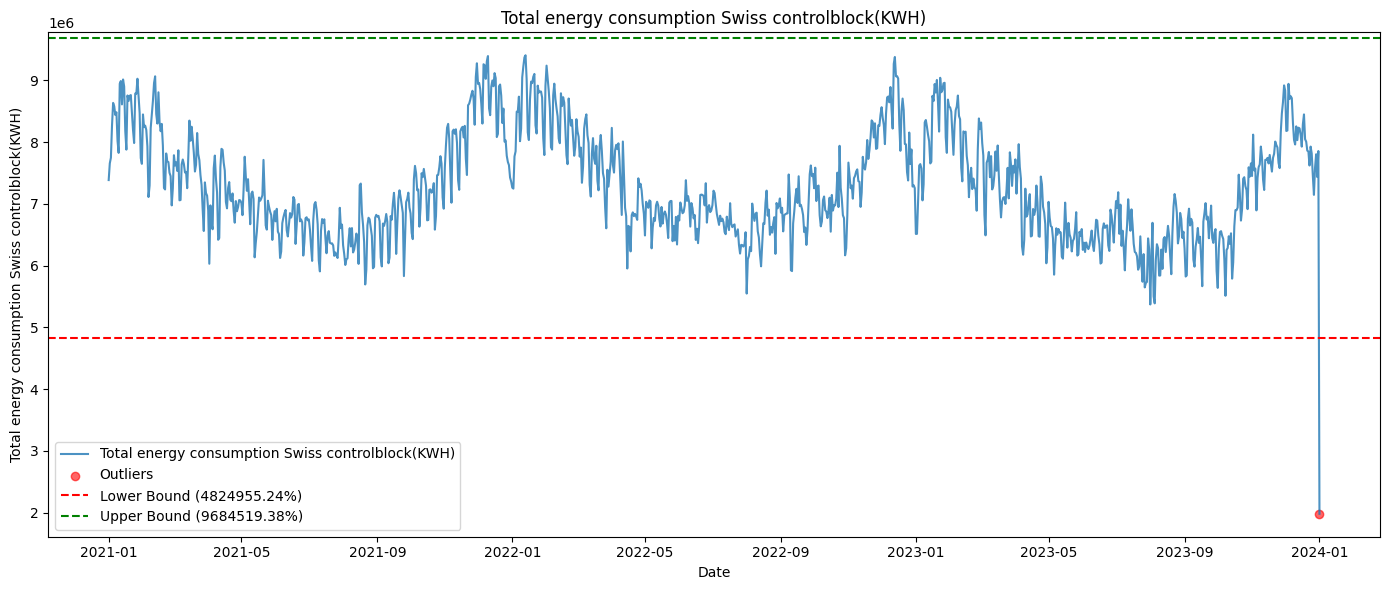

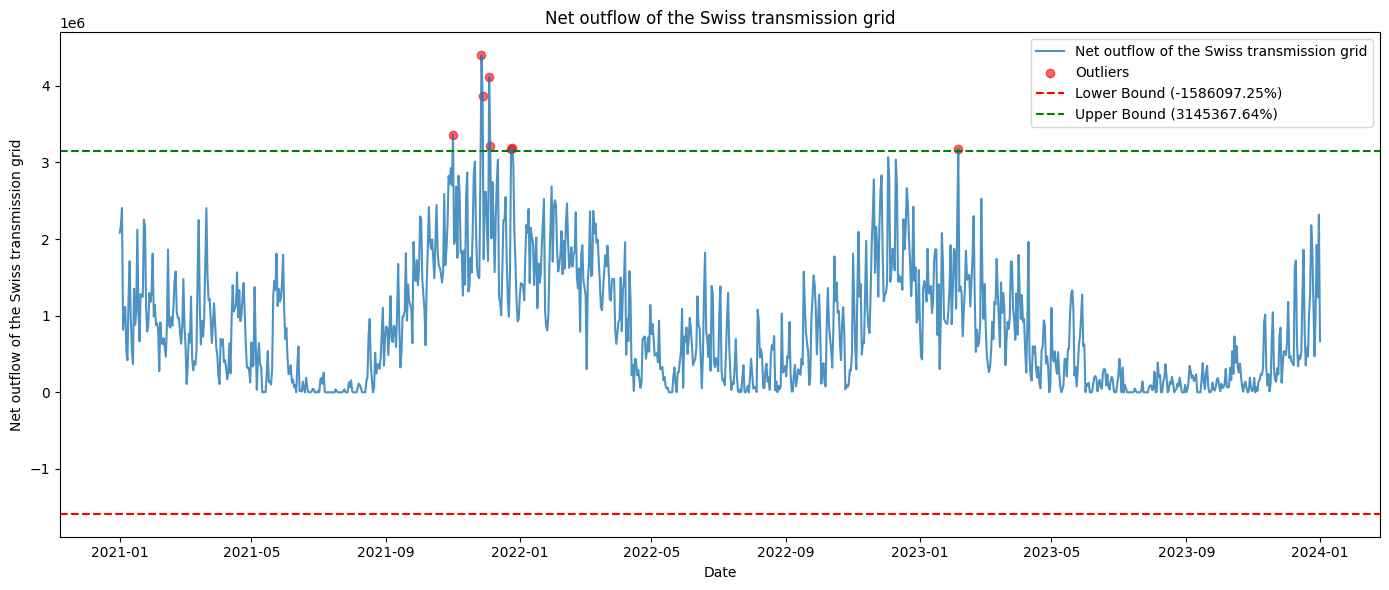

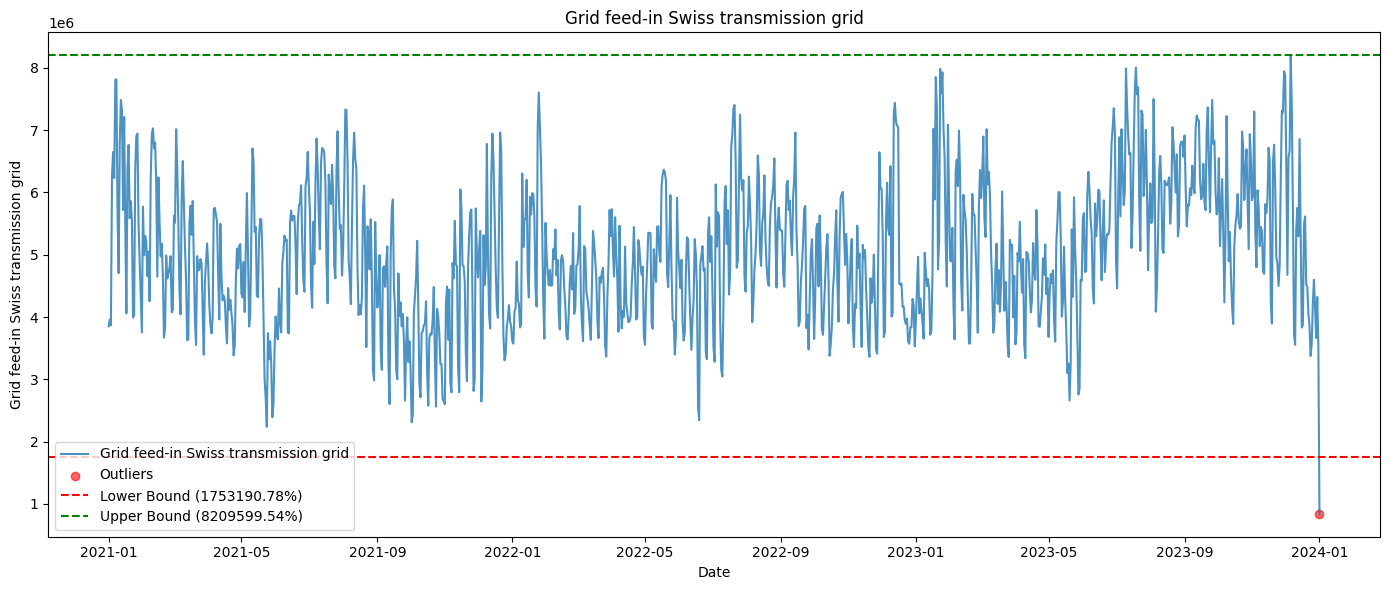

In [18]:
# plot daily outlier
for column in df_energy_plots.data.columns:
    df_energy_plots.outlier_plot(column_name=column,title=f'{column}',group_by='day')

### Hourly

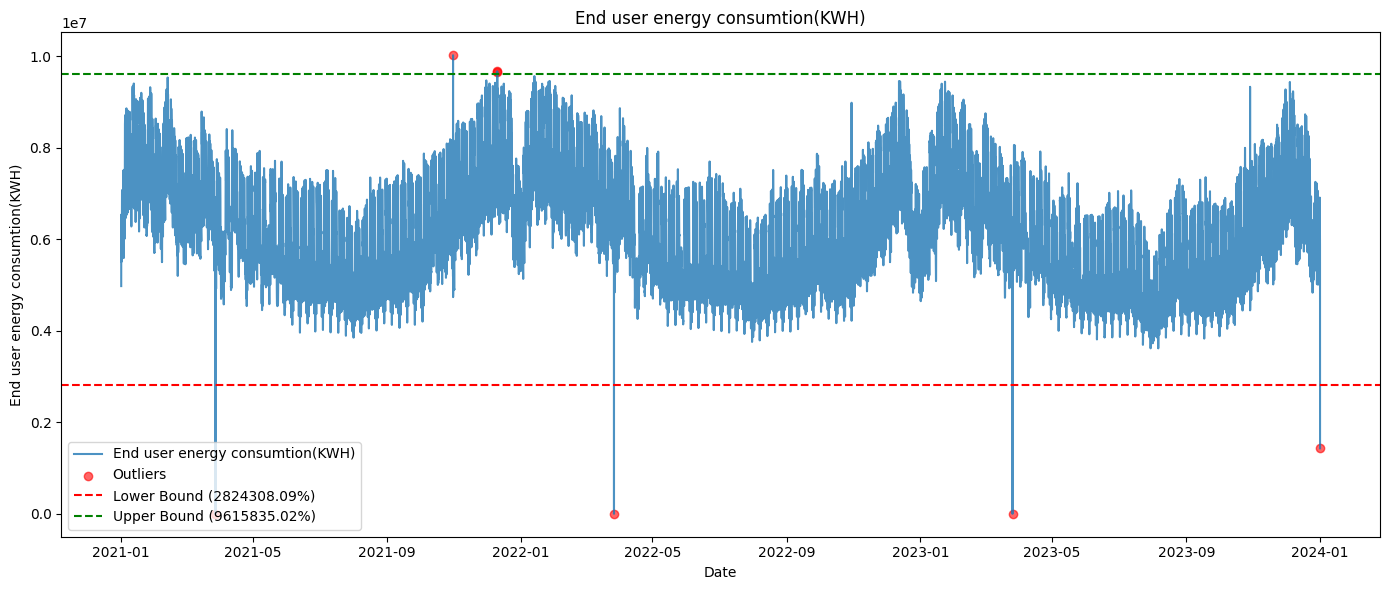

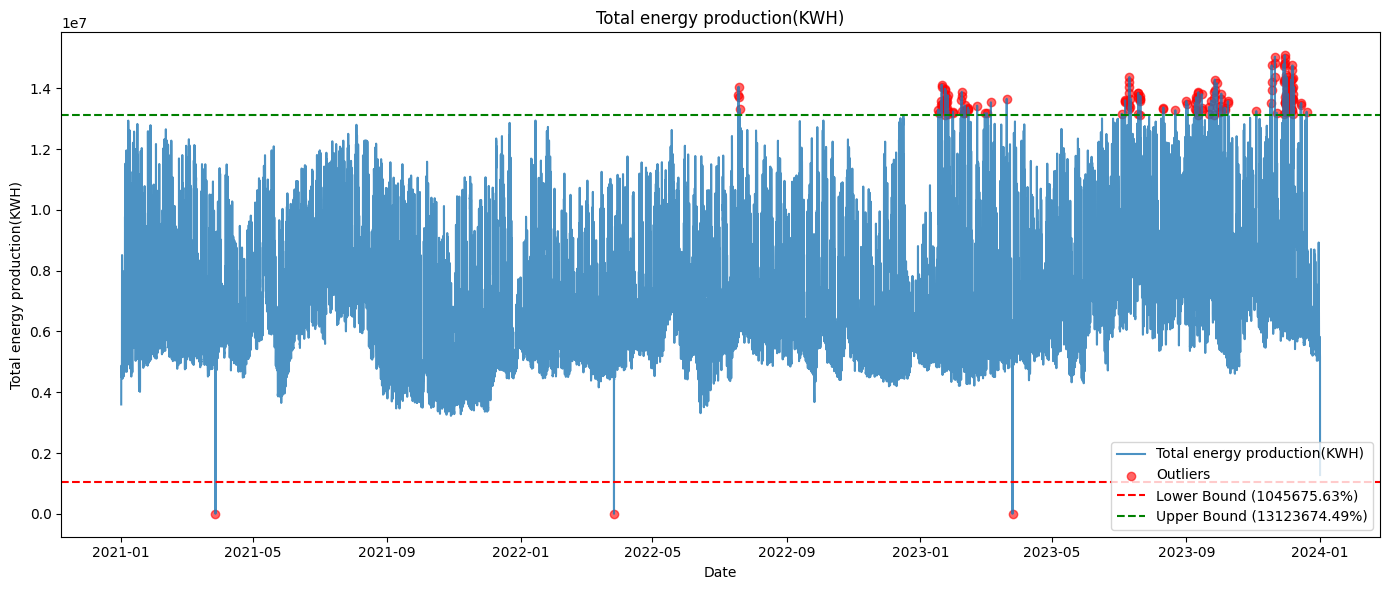

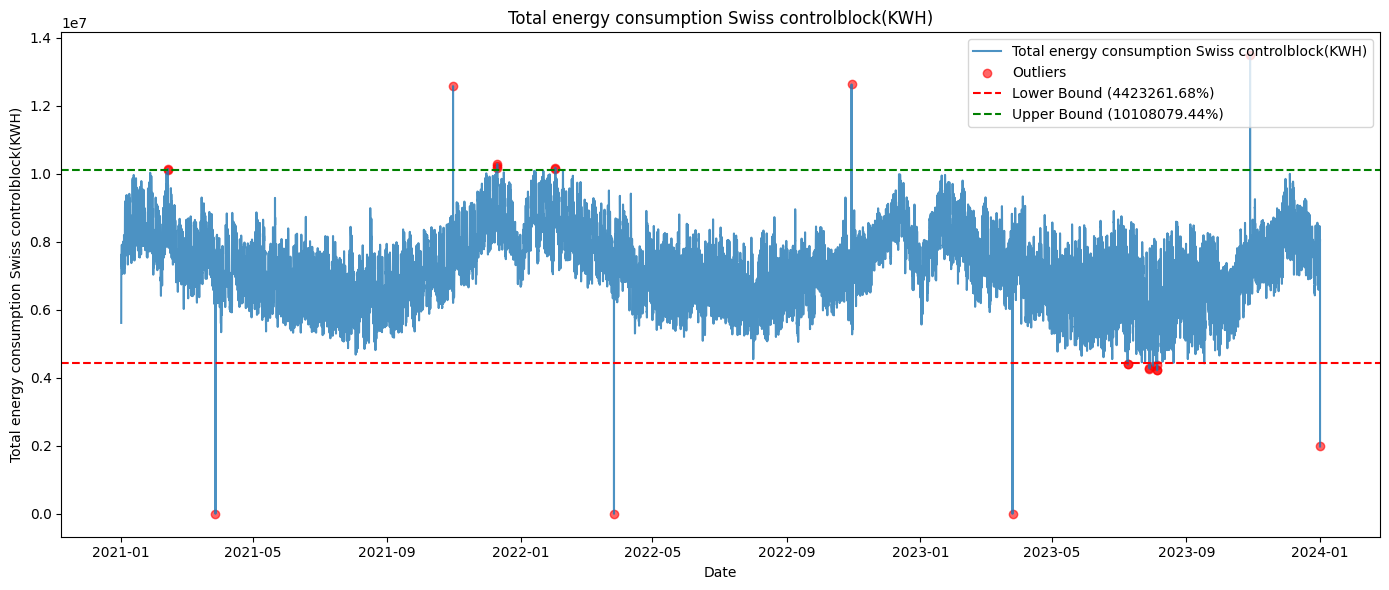

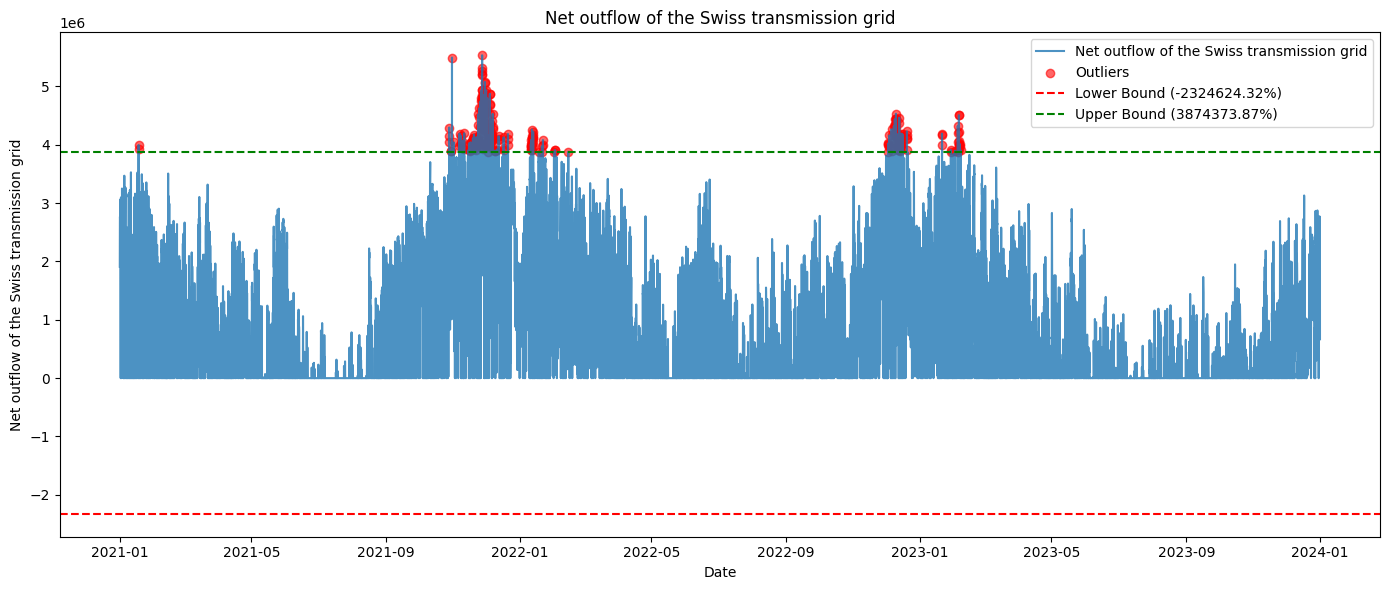

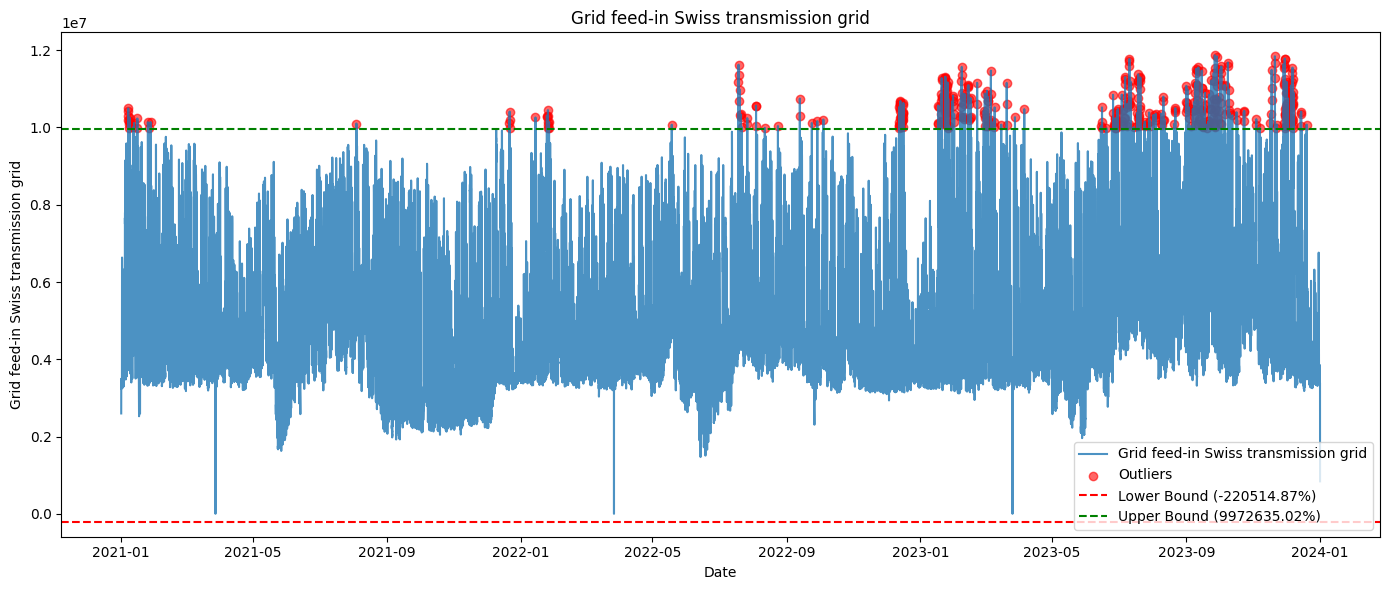

In [19]:
# plot hourly outlier
for column in df_energy_plots.data.columns:
    df_energy_plots.outlier_plot(column_name=column,title=f'{column}',group_by='hour')

## Plot hourly

In [20]:
columns=['End user energy consumtion(KWH)', 'Total energy production(KWH)',
       'Total energy consumption Swiss controlblock(KWH)',
       'Net outflow of the Swiss transmission grid',
       'Grid feed-in Swiss transmission grid']

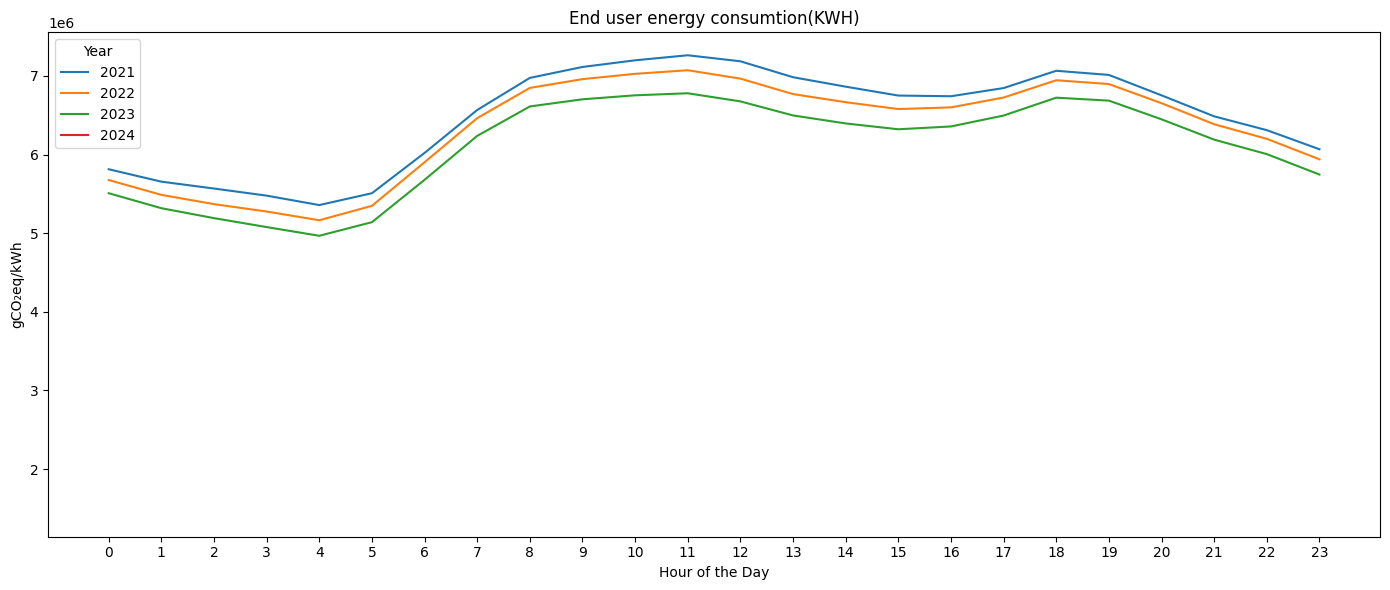

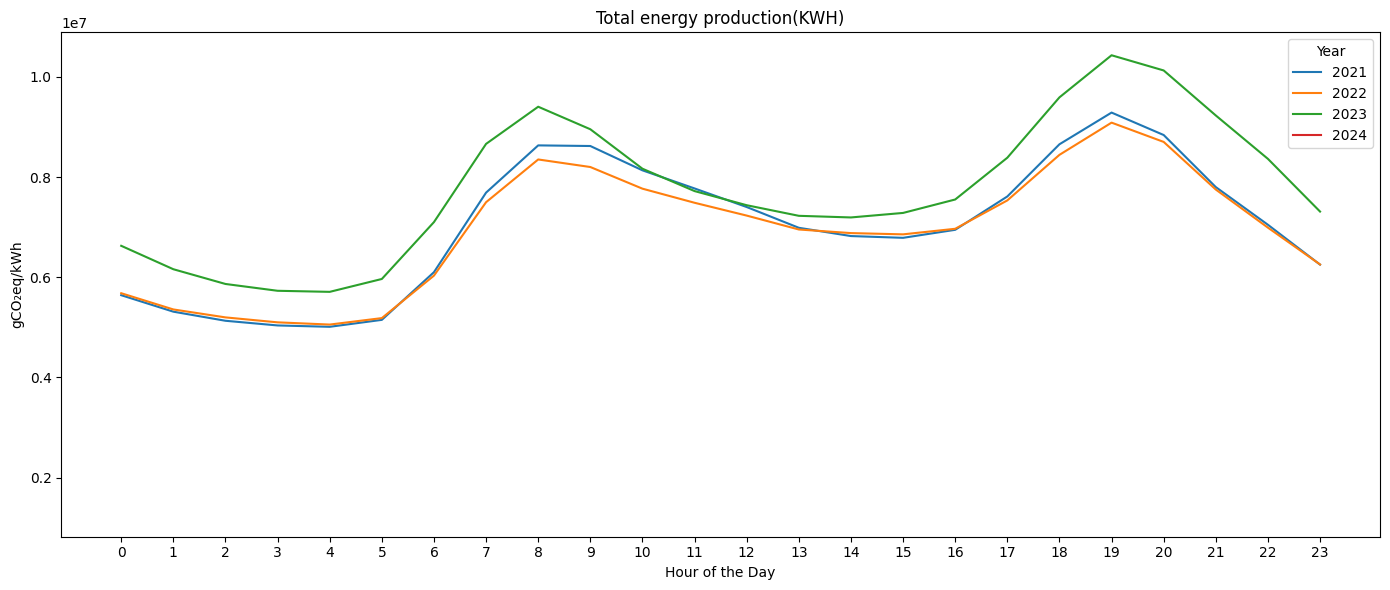

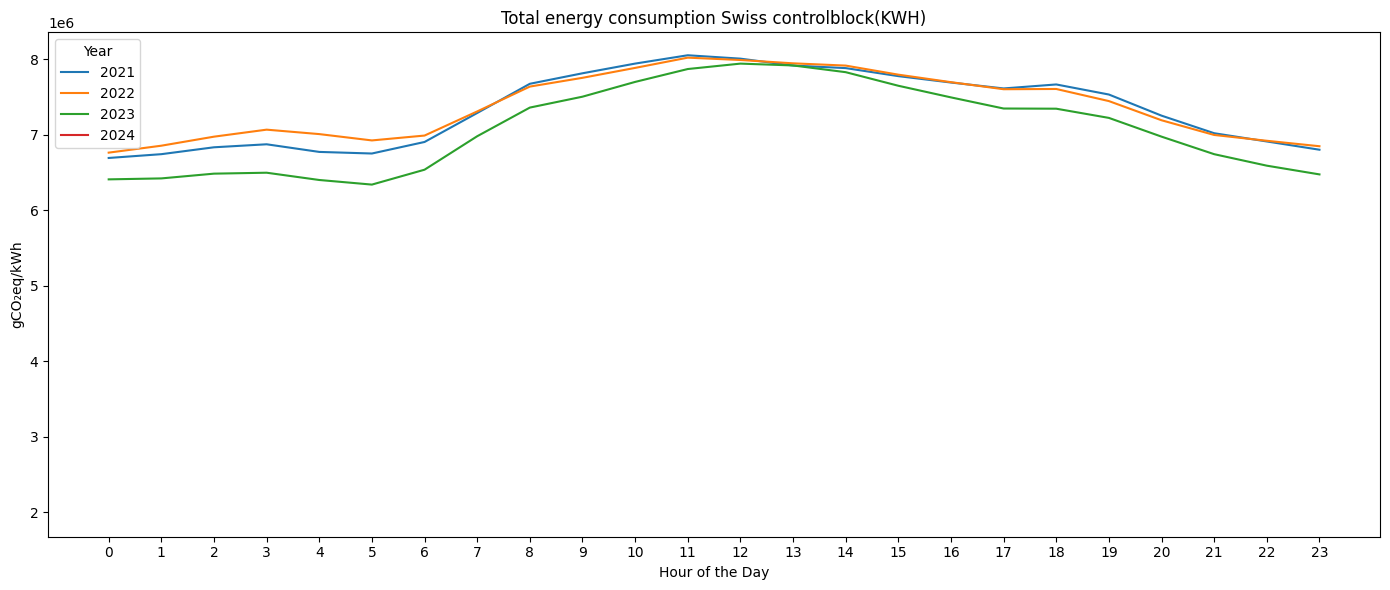

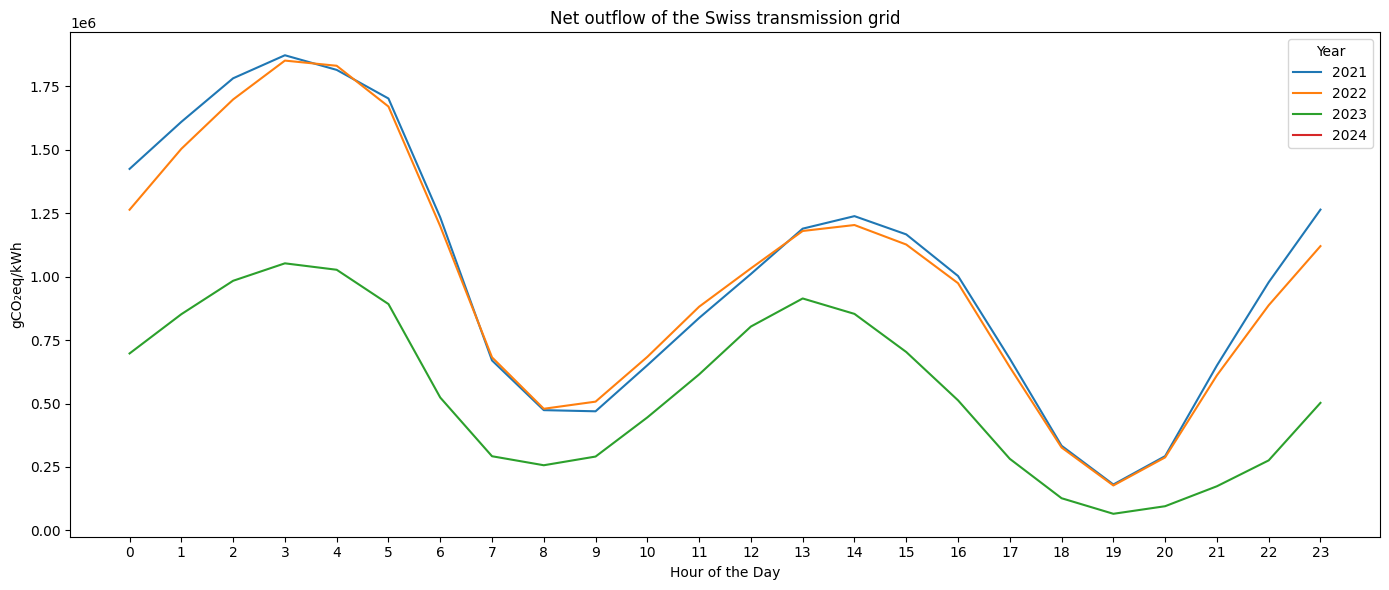

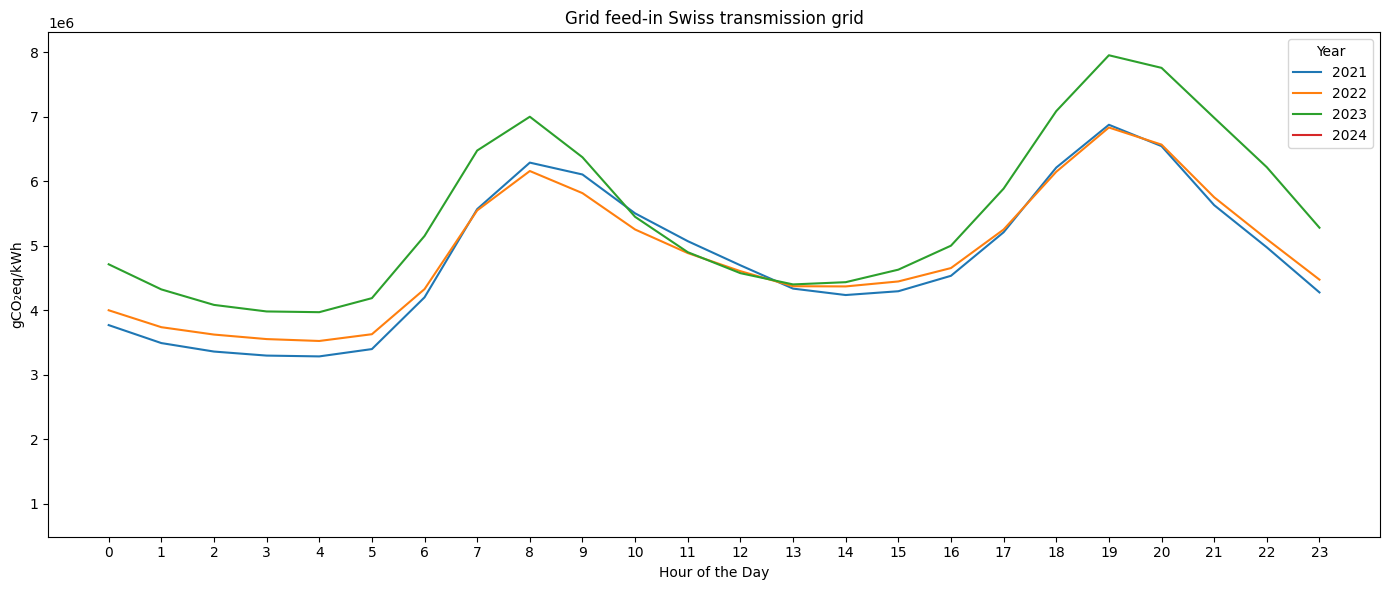

In [21]:
# hourly average energy production,consumption and grid feed and net outflow
for column in columns:
   df_energy_plots.plot_hourly_trends(columns=[column],
    title=f"{column}",
    ylabel="gCO₂eq/kWh")
  

## Plot Daily

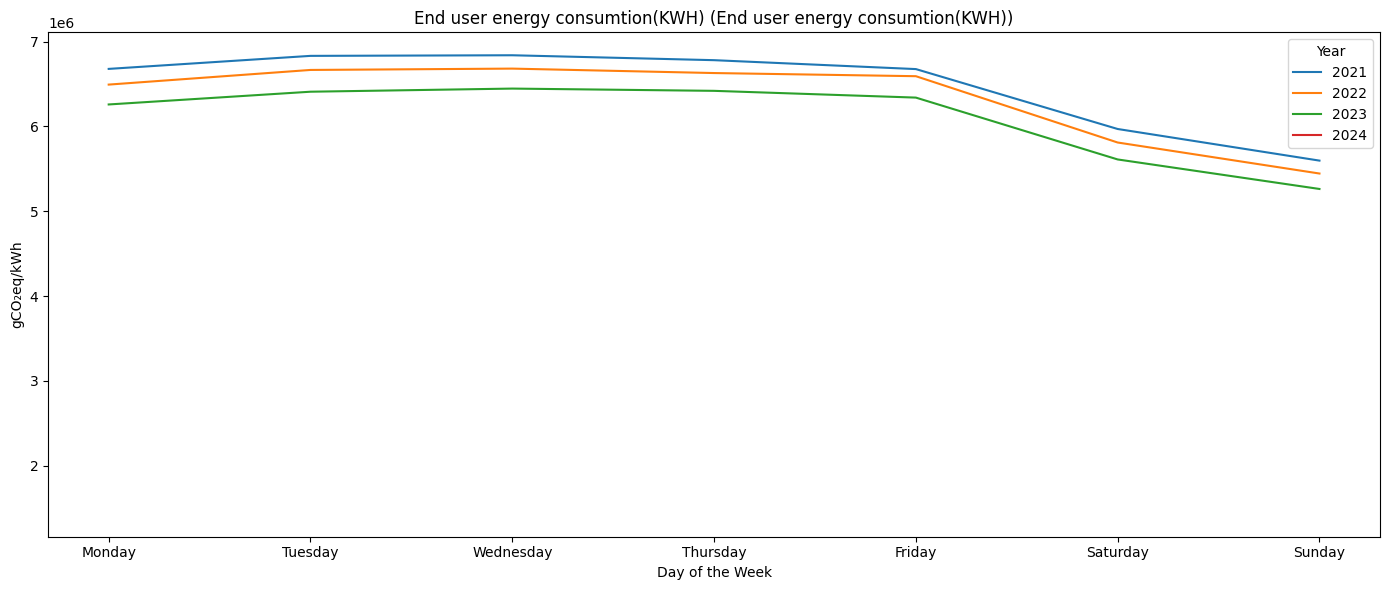

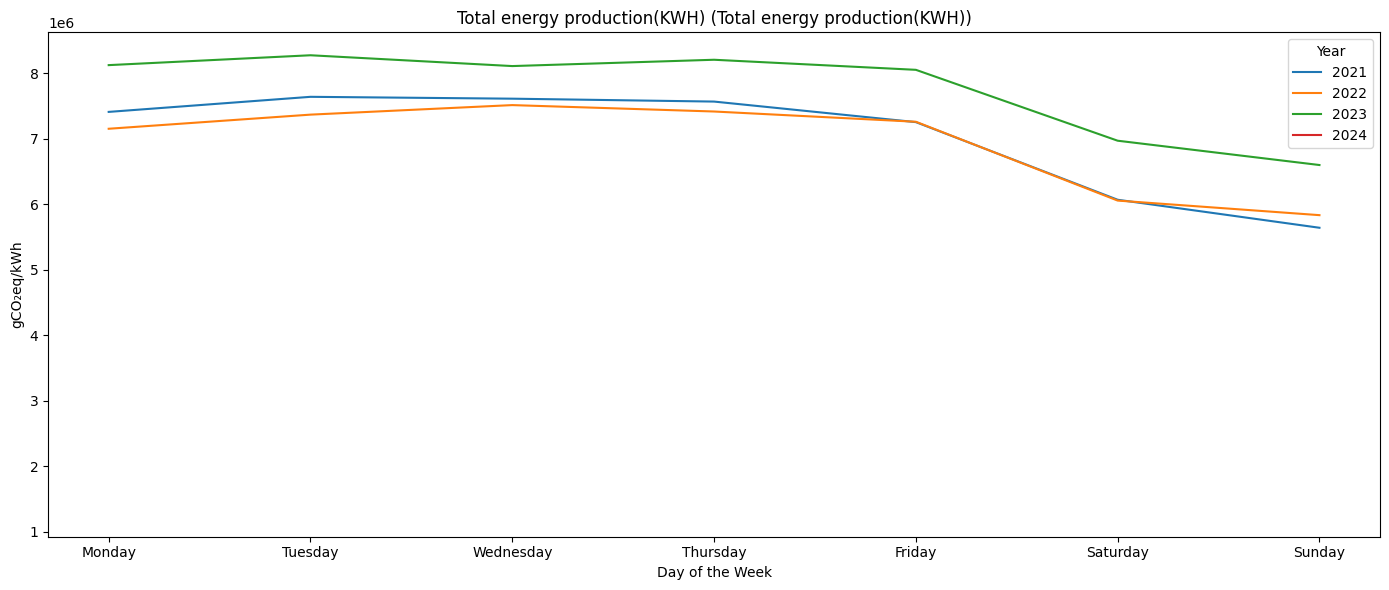

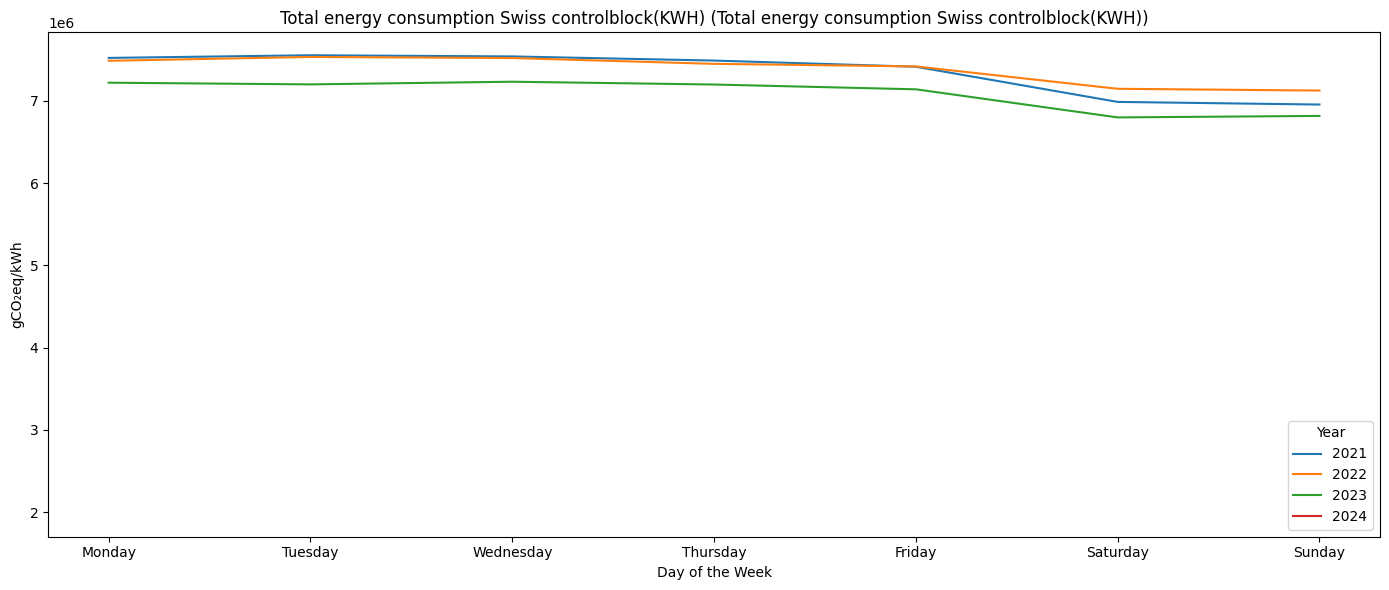

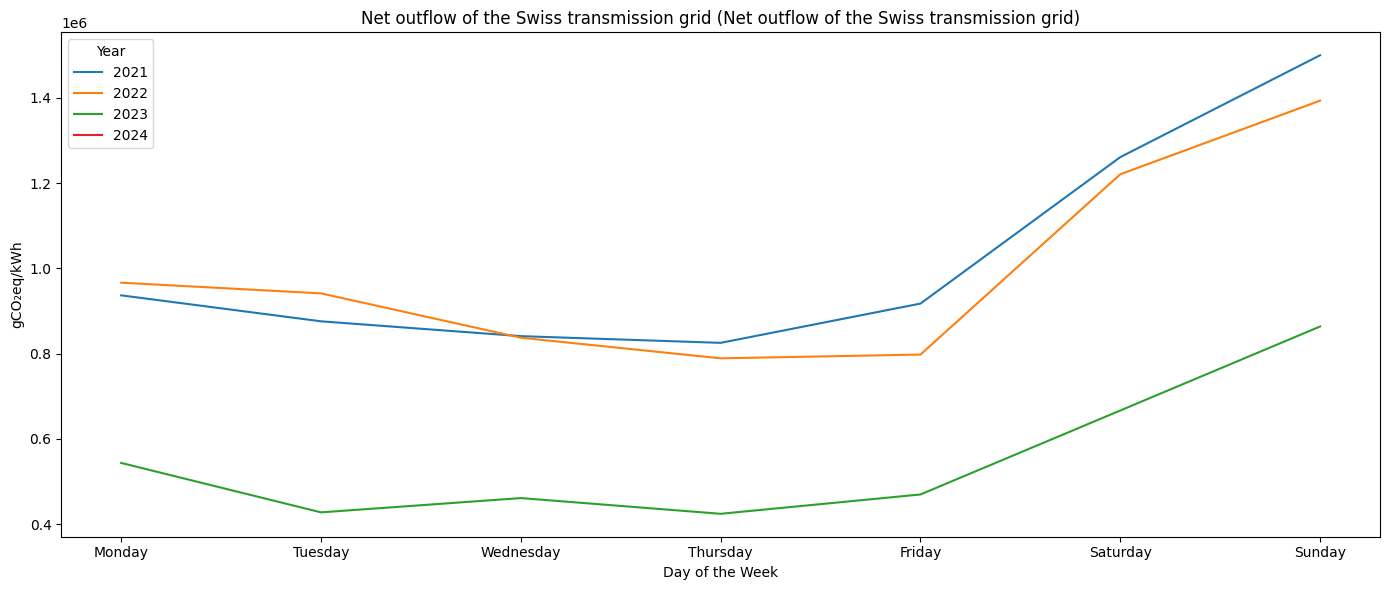

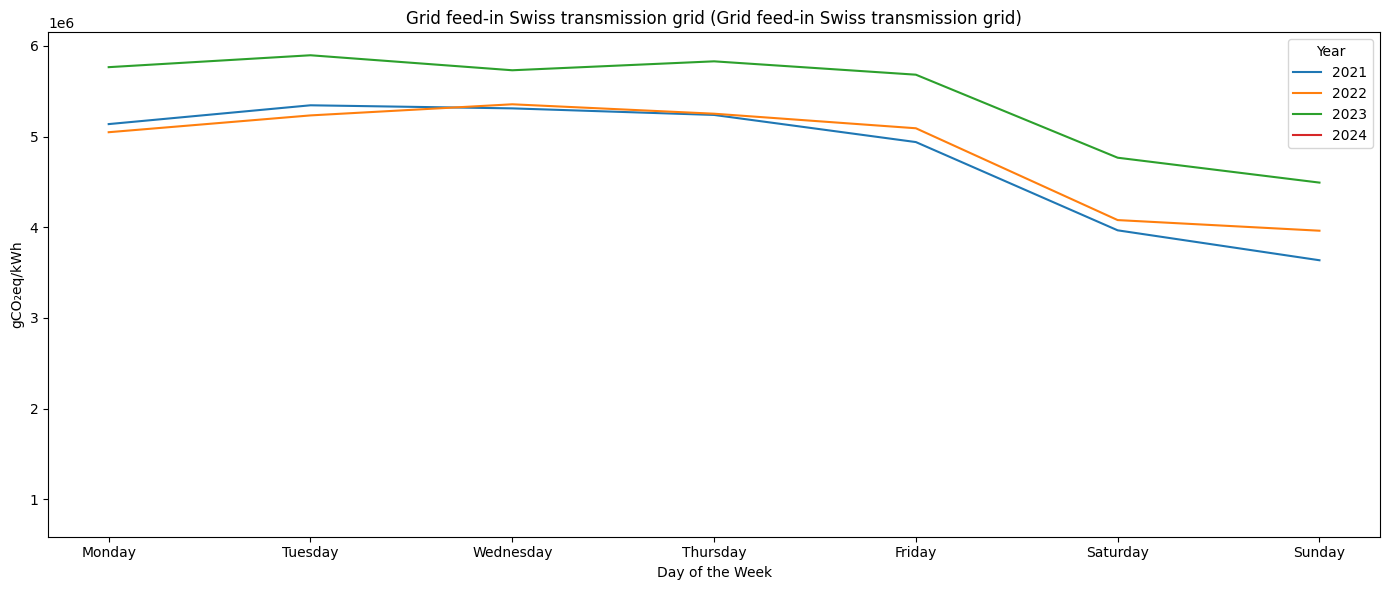

In [22]:
# daily data
for column in columns:
   df_energy_plots.plot_weekday_trends(columns=[column],
    title=f"{column}",
    ylabel="gCO₂eq/kWh")

## Plot monthly

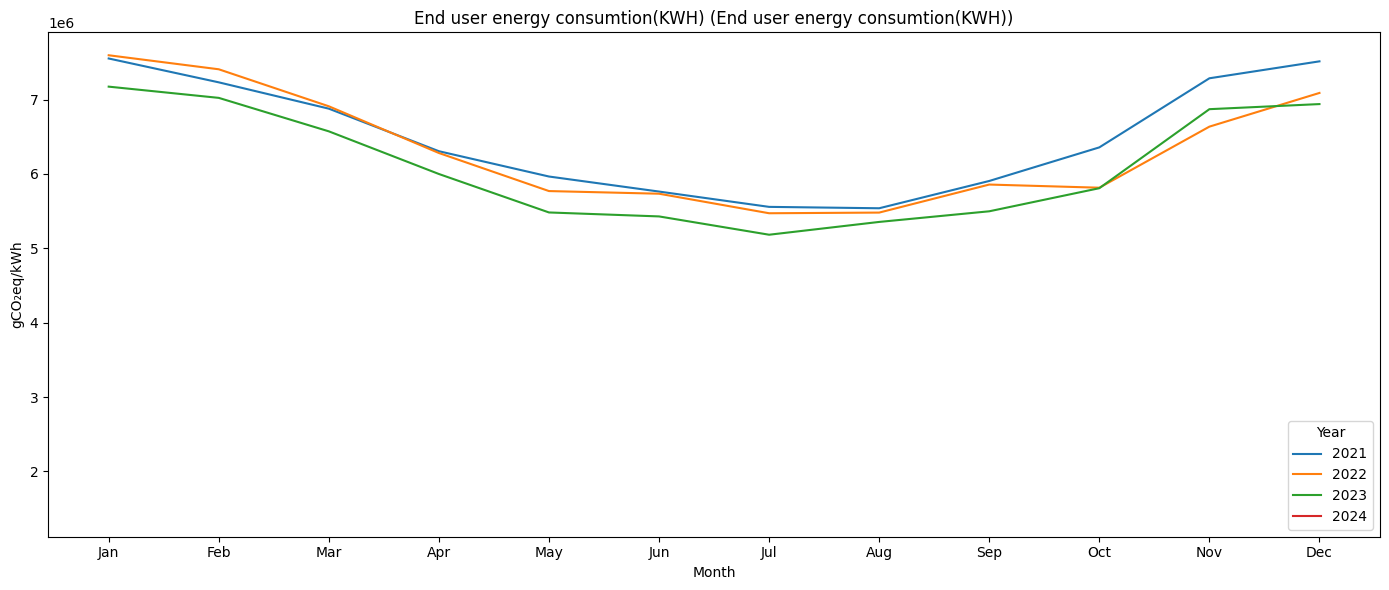

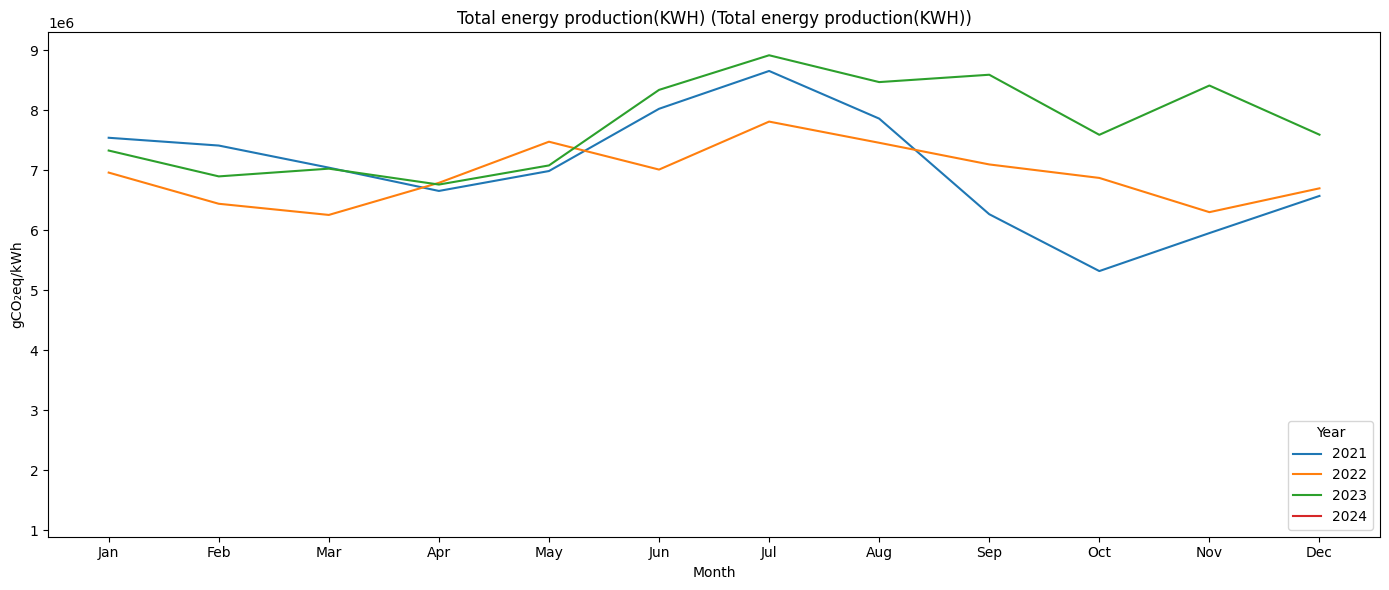

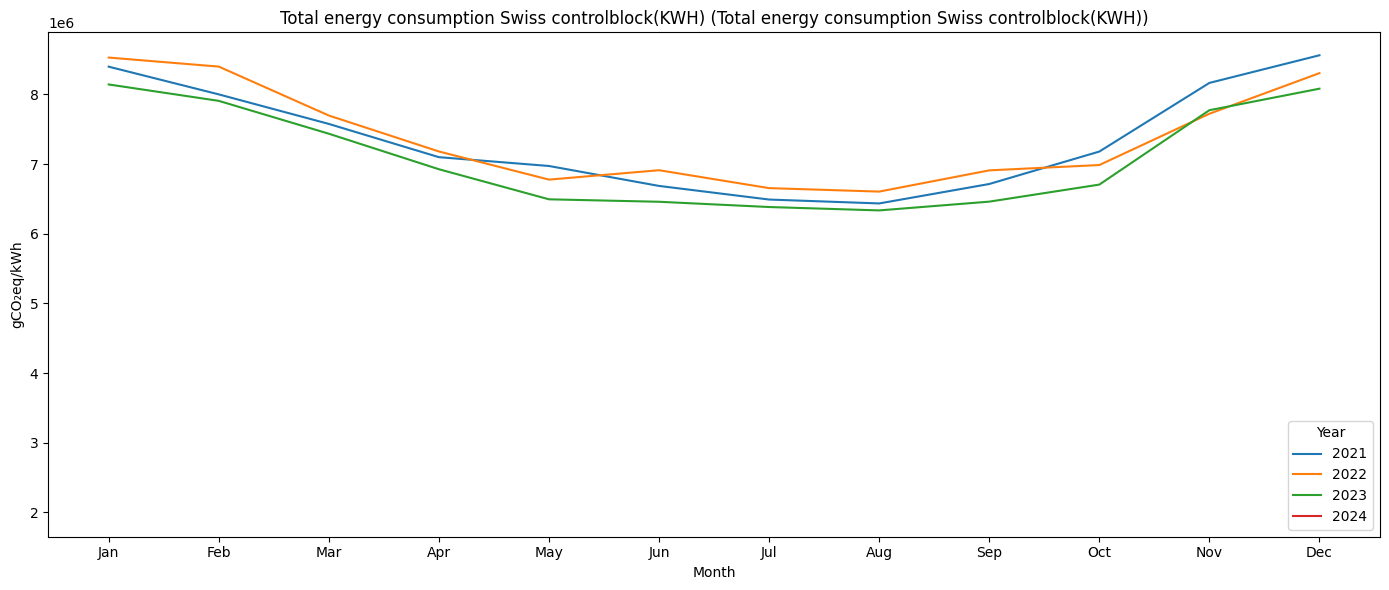

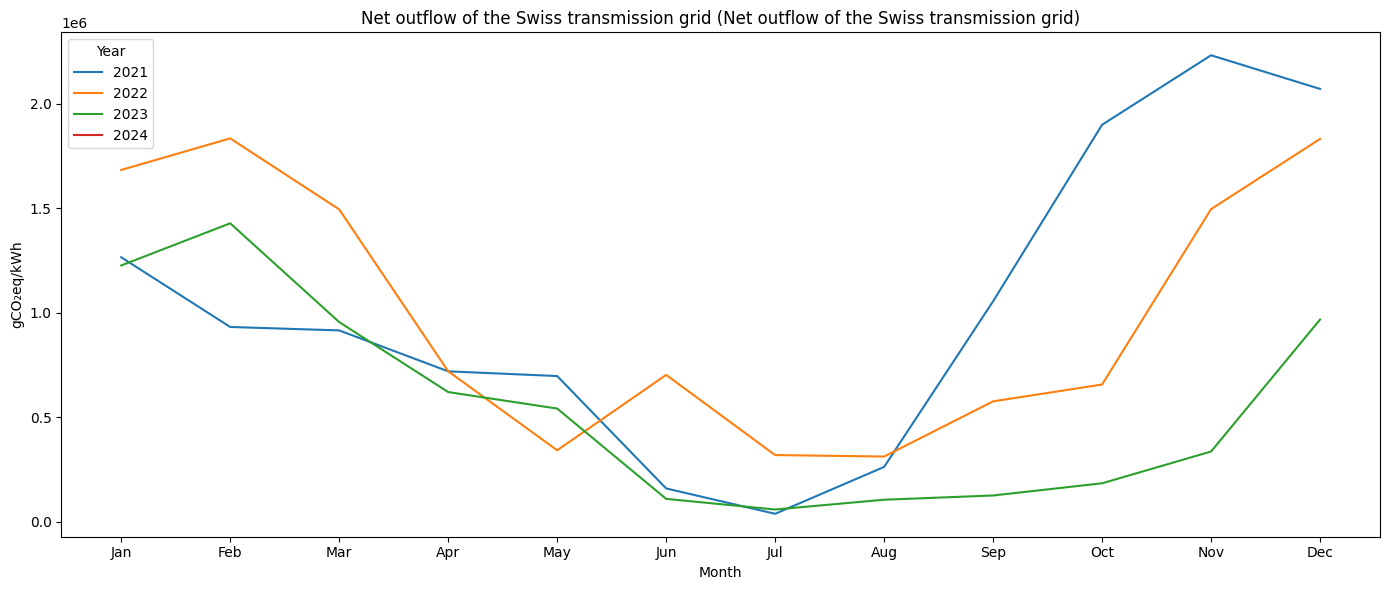

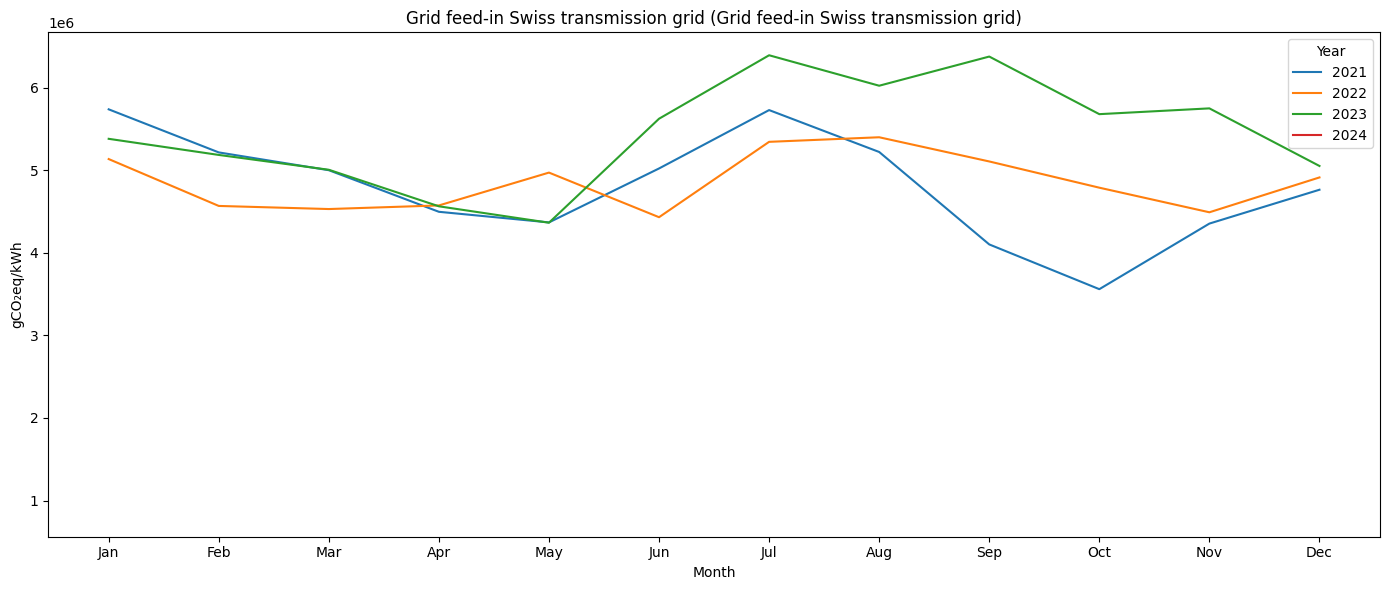

In [23]:
## plot monthly
for column in columns:
   df_energy_plots.plot_monthly_trends(columns=[column],
    title=f"{column}",
    ylabel="gCO₂eq/kWh")


example

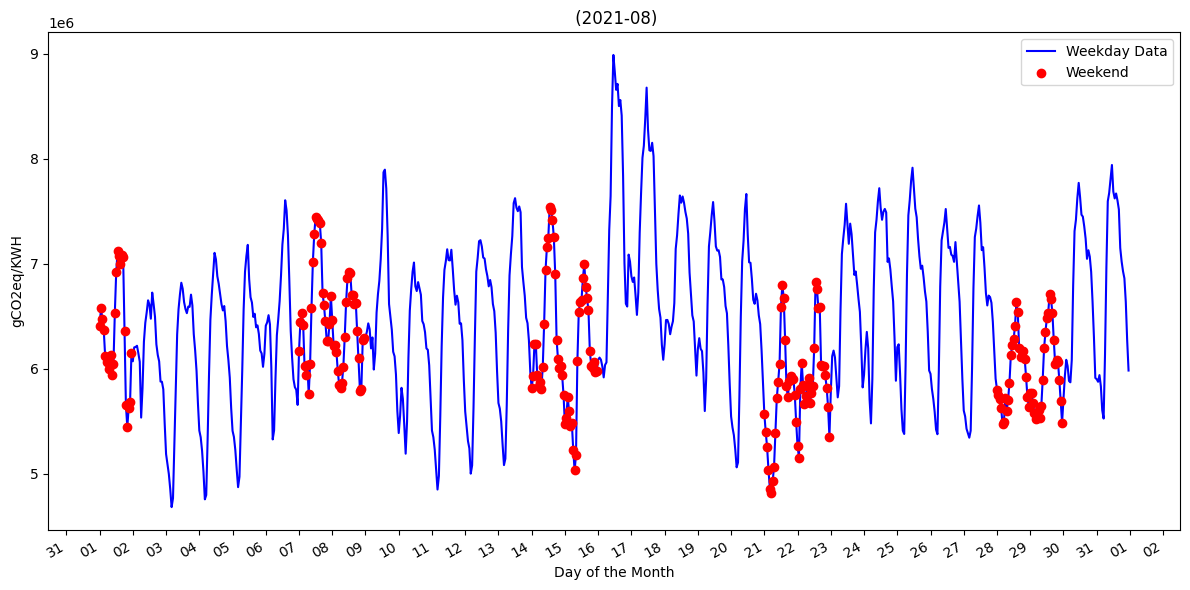

In [24]:
df_energy_plots.plot_month_with_weekends(
    column='Total energy consumption Swiss controlblock(KWH)',
    year=2021,
    month=8,
    title="",
    ylabel="gCO2eq/KWH"
)